In [2]:
import pandas as pd
import numpy as np
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GroupKFold
import pickle

In [3]:
data_path = "/Users/harry/Documents/3rd Year/Project/Storm_building/storm_dataset_96.csv"
storms = pd.read_csv(data_path)

MAX_LAG = 10
N_FEATURES = 5
BATCH_SIZE = 64
EPOCHS = 32
PATIENCE = 4
EXCLUDE = ["Datetime","storm_number", "Dst_t+3"]
INCLUDE = [col for col in storms.columns if col not in EXCLUDE]

print(f"Storm labels (unique storms):\n{storms['storm_number'].unique()}")
print(f"Shape of data set: {storms.shape}")
print(f"Features used: {storms.columns}")

Storm labels (unique storms):
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
Shape of data set: (9700, 53)
Features used: Index(['Datetime', 'Bz_GSM_t-9', 'Bz_GSM_t-8', 'Bz_GSM_t-7', 'Bz_GSM_t-6',
       'Bz_GSM_t-5', 'Bz_GSM_t-4', 'Bz_GSM_t-3', 'Bz_GSM_t-2', 'Bz_GSM_t-1',
       'Bz_GSM_t-0', 'Bz_GSE_t-9', 'Bz_GSE_t-8', 'Bz_GSE_t-7', 'Bz_GSE_t-6',
       'Bz_GSE_t-5', 'Bz_GSE_t-4', 'Bz_GSE_t-3', 'Bz_GSE_t-2', 'Bz_GSE_t-1',
       'Bz_GSE_t-0', 'Plasma_Speed_t-9', 'Plasma_Speed_t-8',
       'Plasma_Speed_t-7', 'Plasma_Speed_t-6', 'Plasma_Speed_t-5',
       'Plasma_Speed_t-4', 'Plasma_Speed_t-3', 'Plasma_Speed_t-2',
       'Plasma_Sp

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


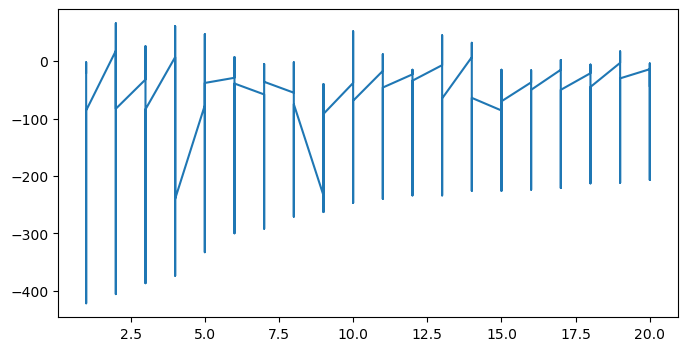

In [4]:
top_20 = storms[storms["storm_number"] < 21]
len(top_20["storm_number"].unique())

plt.figure(figsize = (8, 4))
plt.plot(top_20["storm_number"], top_20["Dst_t+3"])

print(top_20.storm_number.unique())

In [5]:
def train_model(max_lag, n_features):
    model = keras.Sequential([
        keras.layers.Input(shape=(max_lag, n_features)),
        keras.layers.LayerNormalization(),
        keras.layers.LSTM(64, return_sequences = True, dropout = 0.2, recurrent_dropout = 0.1),
        keras.layers.LSTM(32, dropout = 0.2),
        keras.layers.Dense(16, activation = "relu"),
        keras.layers.Dense(1)
    ])
    
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
        loss = keras.losses.Huber(delta = 20.0),
        metrics = ["mae"]
    )
    return model


def copy_model(model):
    clone = keras.models.clone_model(model)
    clone.set_weights(model.get_weights())
    clone.compile(
        optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
        loss = keras.losses.Huber(delta = 20.0),
        metrics = ["mae"]
    )
    return clone


def sequence(X_flat, n_features = 5, max_lag = 10):

    n = X_flat.shape[0]
    X = X_flat.reshape(n, n_features, max_lag)
    X = X.transpose(0, 2, 1)
    return X

def scale_data(x, y, x_scaler = None, y_scaler = None, fit = False):
    if fit:
        x_scaler = MinMaxScaler()
        y_scaler = MinMaxScaler()
        X_scaled = x_scaler.fit_transform(x)
        Y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()
    else:
        X_scaled = x_scaler.transform(x)
        Y_scaled = y_scaler.transform(y.reshape(-1, 1)).ravel()
    return X_scaled, Y_scaled, x_scaler, y_scaler

def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"mse": mse, "mae": mae, "rmse": rmse}

def online_predict(model, X, y, param, callbacks):
    """
    Online prediction with incremental model updates.
    """    
    test_SE = []
    results = []
    for t in range(len(X)):
        n, epochs = param
        if t >= n:
            model.fit(X[t - n: t], y[t - n: t], epochs = epochs, verbose = 0, callbacks = callbacks)
            
        yhat = model.predict(X[t: t + 1], verbose = 0)[0, 0]
        ytrue = y[t]
        test_SE.append((ytrue - yhat) ** 2)
        results.append((ytrue, yhat))
    return test_SE, results

def online_predict(model, X, y, n, epochs):
    for t in range(len(X)):
        if t >= n:
            model.fit(X[t-n:t], y[t-n:t], epochs=epochs, verbose=0)

        yhat = model.predict(X[t:t+1])[0, 0]
        error = (y[t] - yhat)**2
    return error

In [6]:
for test_storm in top_20.storm_number.unique():
    test_data = storms.loc[storms["storm_number"] == test_storm].copy()
    train_data = storms.loc[storms["storm_number"] != test_storm].copy()

    Xtest = test_data[INCLUDE].values
    ytest = test_data["Dst_t+3"].values
    X = train_data[INCLUDE].values
    y = train_data["Dst_t+3"].values

    groups = train_data["storm_number"].values
    print(f"Test storm: {test_storm}, Length test: {len(Xtest)}, Shape test: {Xtest.shape}")

Test storm: 1, Length test: 97, Shape test: (97, 50)
Test storm: 2, Length test: 97, Shape test: (97, 50)
Test storm: 3, Length test: 97, Shape test: (97, 50)
Test storm: 4, Length test: 97, Shape test: (97, 50)
Test storm: 5, Length test: 97, Shape test: (97, 50)
Test storm: 6, Length test: 97, Shape test: (97, 50)
Test storm: 7, Length test: 97, Shape test: (97, 50)
Test storm: 8, Length test: 97, Shape test: (97, 50)
Test storm: 9, Length test: 97, Shape test: (97, 50)
Test storm: 10, Length test: 97, Shape test: (97, 50)
Test storm: 11, Length test: 97, Shape test: (97, 50)
Test storm: 12, Length test: 97, Shape test: (97, 50)
Test storm: 13, Length test: 97, Shape test: (97, 50)
Test storm: 14, Length test: 97, Shape test: (97, 50)
Test storm: 15, Length test: 97, Shape test: (97, 50)
Test storm: 16, Length test: 97, Shape test: (97, 50)
Test storm: 17, Length test: 97, Shape test: (97, 50)
Test storm: 18, Length test: 97, Shape test: (97, 50)
Test storm: 19, Length test: 97, Shap

In [7]:
CV = GroupKFold(n_splits = 4)
no_epochs = np.array([1, 2, 5])
no_data_points = np.array([1, 2, 5])
m = len(no_epochs) * len(no_data_points)

outer_loop_history = {}
output = {}
outer_loop_counter = 0

In [8]:
for test_storm in top_20.storm_number.unique():
    test_data = storms.loc[storms["storm_number"] == test_storm].copy()
    train_data = storms.loc[storms["storm_number"] != test_storm].copy()

    Xtest = test_data[INCLUDE].values
    ytest = test_data["Dst_t+3"].values
    X = train_data[INCLUDE].values
    y = train_data["Dst_t+3"].values

    groups = train_data["storm_number"].values
    param_scores = {(n, e): [] for n in no_data_points for e in no_epochs}

    _, _, x_scaler_outer, y_scaler_outer = scale_data(X, y, fit = True)

    for fold , (train_idx, val_idx) in enumerate(CV.split(X, y, groups)):
        Xtrain = X[train_idx]
        Xval = X[val_idx]
        ytrain = y[train_idx]
        yval = y[val_idx]

        Xtrain_scaled, ytrain_scaled, x_scaler_inner, y_scaler_inner = scale_data(Xtrain, ytrain, fit = True)
        Xval_scaled, yval_scaled, _, _ = scale_data(Xval, yval, x_scaler = x_scaler_inner, y_scaler = y_scaler_inner, fit = False)

        Xtrain_seq = sequence(Xtrain_scaled)
        Xval_seq = sequence(Xval_scaled)

        base_model = train_model(max_lag = MAX_LAG, n_features = N_FEATURES)
        callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = PATIENCE, restore_best_weights = True),
                     keras.callbacks.ReduceLROnPlateau(monitor = "val_loss", factor = 0.5, patience = PATIENCE)]
        callbacks_val = [keras.callbacks.EarlyStopping(monitor = "loss", patience = PATIENCE, restore_best_weights = True),
                         keras.callbacks.ReduceLROnPlateau(monitor = "loss", factor = 0.5, patience = PATIENCE)]
        
        history = base_model.fit(
            Xtrain_seq,
            ytrain_scaled,
            validation_data = (Xval_seq, yval_scaled),
            epochs = EPOCHS,
            callbacks = callbacks,
            batch_size = BATCH_SIZE,
            verbose = 0
        )

        T = min(len(Xval_seq), len(yval_scaled)) 

        m_idx = 0    
        for n in no_data_points:
            for epochs in no_epochs:
                m_idx += 1
                S_E = []
                online_model = copy_model(base_model)
                
                for t in range(n, T):
                    """online_model = clone_model(base_model)"""
                    online_model.fit(
                        Xval_seq[t - n: t], 
                        yval_scaled[t - n: t],
                        epochs = epochs, 
                        verbose = 0,
                        callbacks = callbacks_val
                    )
                    
                    ypred_online = online_model.predict(Xval_seq[t: t + 1], verbose = 0)[0, 0] 
                    y_true = yval_scaled[t]
                    y_true = y_scaler_inner.inverse_transform([[y_true]])[0, 0]
                    ypred_online = y_scaler_inner.inverse_transform([[ypred_online]])[0, 0]
                    S_E.append((y_true - ypred_online) ** 2)

                online_RMSE = np.sqrt(np.mean(S_E))
                param_scores[(n, epochs)].append((online_RMSE, fold + 1))
                print(f"Fold {fold + 1}/{CV.n_splits}, Parameter set {m_idx}/{m}, Online RMSE: {online_RMSE:.4f}")   

    Xtest_scaled, ytest_scaled, _, _ = scale_data(
        Xtest, 
        ytest, 
        x_scaler =  x_scaler_outer, 
        y_scaler = y_scaler_outer, 
        fit = False
    )
    X_ALL_scaled, y_ALL_scaled, _, _ = scale_data(
        X, 
        y, 
        x_scaler = x_scaler_outer, 
        y_scaler = y_scaler_outer, 
        fit = False
    )
    
    X_ALL_seq = sequence(X_ALL_scaled)    
    Xtest_seq = sequence(Xtest_scaled)

    best_model = train_model(MAX_LAG, N_FEATURES)
    best_param = min(
        param_scores.keys(), 
        key = lambda k: np.mean([x[0] for x in param_scores[k]])
    )

    best_model.fit(
        X_ALL_seq,
        y_ALL_scaled,
        epochs = EPOCHS,
        verbose = 0,
        callbacks = callbacks_val
    )
    
    y_pred_test = []
    test_SE = []

    n, epochs = best_param
    for t in range(n, len(Xtest_seq)):
        best_model.fit(
            Xtest_seq[t - n: t],
            ytest_scaled[t - n: t],
            epochs = epochs,
            verbose = 0,
            callbacks = callbacks_val
        )
        yhat = best_model.predict(Xtest_seq[t: t + 1], verbose = 0)[0, 0]
        ytrue = ytest_scaled[t]
        ytrue = y_scaler_outer.inverse_transform([[ytrue]])[0, 0]
        yhat = y_scaler_outer.inverse_transform([[yhat]])[0, 0]
        y_pred_test.append(yhat)
        test_SE.append((ytrue - yhat) ** 2)

    y_pred_test = np.array(y_pred_test)

    outer_loop_history[outer_loop_counter] = {
        "test_storm": test_storm,
        "best_param": best_param,
        "param_scores": param_scores,
        "test_score": np.sqrt(np.mean(test_SE))
    }
    output[outer_loop_counter] = {
        "y_true": ytest,
        "y_pred": y_pred_test
    }

    outer_loop_counter += 1 
    print("="*10 + f"{outer_loop_counter}" + "="*10)

Fold 1/4, Parameter set 1/9, Online RMSE: 30.1568
Fold 1/4, Parameter set 2/9, Online RMSE: 23.9915
Fold 1/4, Parameter set 3/9, Online RMSE: 37.8398
Fold 1/4, Parameter set 4/9, Online RMSE: 31.4940
Fold 1/4, Parameter set 5/9, Online RMSE: 25.9860
Fold 1/4, Parameter set 6/9, Online RMSE: 38.9570
Fold 1/4, Parameter set 7/9, Online RMSE: 34.7053
Fold 1/4, Parameter set 8/9, Online RMSE: 28.3038
Fold 1/4, Parameter set 9/9, Online RMSE: 39.4836
Fold 2/4, Parameter set 1/9, Online RMSE: 36.8059
Fold 2/4, Parameter set 2/9, Online RMSE: 30.3242
Fold 2/4, Parameter set 3/9, Online RMSE: 46.3017
Fold 2/4, Parameter set 4/9, Online RMSE: 37.7883
Fold 2/4, Parameter set 5/9, Online RMSE: 31.1536
Fold 2/4, Parameter set 6/9, Online RMSE: 46.2267
Fold 2/4, Parameter set 7/9, Online RMSE: 42.3269
Fold 2/4, Parameter set 8/9, Online RMSE: 34.2978
Fold 2/4, Parameter set 9/9, Online RMSE: 45.2552
Fold 3/4, Parameter set 1/9, Online RMSE: 32.5559
Fold 3/4, Parameter set 2/9, Online RMSE: 27.4642


In [9]:
"""outer_loop_history = pd.DataFrame(outer_loop_history).T
outer_loop_history.to_csv("outer_loop_history.csv", index = False)"""

'outer_loop_history = pd.DataFrame(outer_loop_history).T\nouter_loop_history.to_csv("outer_loop_history.csv", index = False)'

In [10]:
with open("Results_1_3_5.pkl", "wb") as f:
    pickle.dump((outer_loop_history, output), f)